In [ ]:

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, RandomizedSearchCV
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
# --- 1) Load Data ---
train_path = "train (1).csv"
test_path = "test (1).csv"
sub_path = "sample_submission (1).csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)
sub_df   = pd.read_csv(sub_path)

print(train_df.shape, test_df.shape, sub_df.shape)
train_df.head()

(7613, 5) (3263, 4) (3263, 2)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [ ]:
# --- 2) Quick sanity checks ---
print("Columns:", train_df.columns.tolist())
print("\nTarget distribution:")
print(train_df["target"].value_counts(normalize=True).rename("share"))

print("\nMissing values (train):")
display(train_df.isna().mean().sort_values(ascending=False).to_frame("missing_rate").head(10))

Columns: ['id', 'keyword', 'location', 'text', 'target']

Target distribution:
target
0    0.57034
1    0.42966
Name: share, dtype: float64

Missing values (train):


,missing_rate
location,0.332720
keyword,0.008013
id,0.000000
text,0.000000
target,0.000000


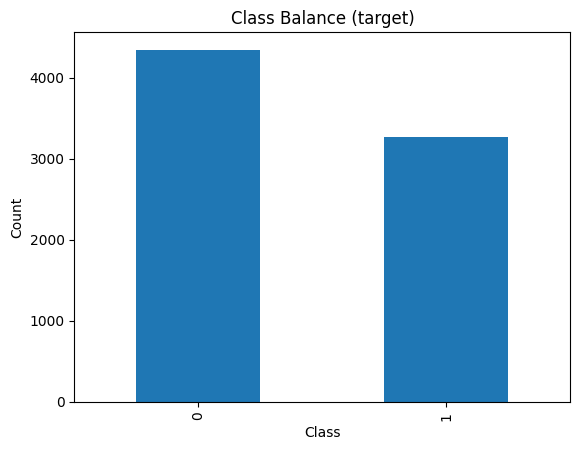

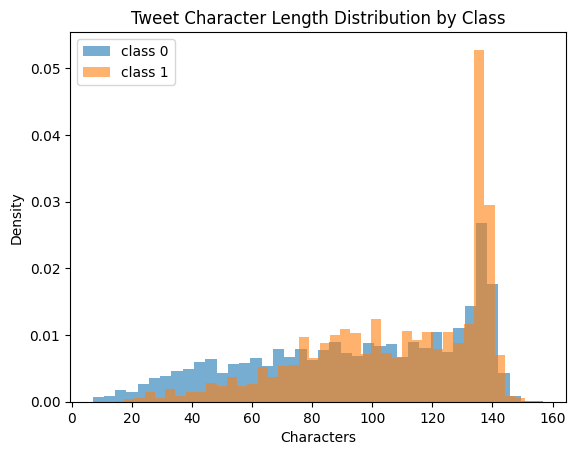

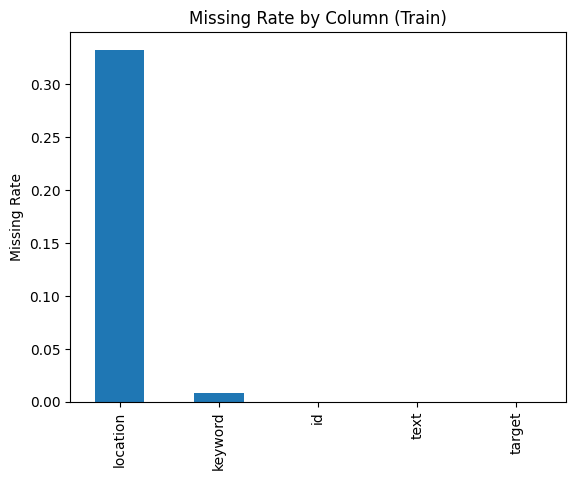

In [ ]:
# --- 3) Basic EDA Graphs ---
plt.figure()
train_df["target"].value_counts().sort_index().plot(kind="bar")
plt.title("Class Balance (target)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Tweet length distribution by class
tmp = train_df.copy()
tmp["char_len"] = tmp["text"].astype(str).str.len()

plt.figure()
for c in [0, 1]:
    tmp[tmp["target"] == c]["char_len"].plot(kind="hist", bins=40, alpha=0.6, density=True, label=f"class {c}")
plt.title("Tweet Character Length Distribution by Class")
plt.xlabel("Characters")
plt.ylabel("Density")
plt.legend()
plt.show()

# Missingness bar chart
miss = train_df.isna().mean().sort_values(ascending=False)
plt.figure()
miss.plot(kind="bar")
plt.title("Missing Rate by Column (Train)")
plt.ylabel("Missing Rate")
plt.show()

In [ ]:
# --- 4) Text cleaning (lightweight, Kaggle-friendly) ---
URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
# Keep hashtags but remove the '#'
HASHTAG_RE = re.compile(r"#(\w+)")
MULTISPACE_RE = re.compile(r"\s+")

def clean_text(s: str) -> str:
    if pd.isna(s):
        return ""
    s = str(s)
    s = s.lower()
    s = URL_RE.sub(" URL ", s)
    s = MENTION_RE.sub(" USER ", s)
    s = HASHTAG_RE.sub(r" \1 ", s)  # "#fire" -> "fire"
    s = s.replace("&amp;", " and ")
    s = re.sub(r"[^a-z0-9\s!?']", " ", s)  # keep basic punctuation
    s = MULTISPACE_RE.sub(" ", s).strip()
    return s

# quick preview
train_df["clean_text_preview"] = train_df["text"].head(10).apply(clean_text)
train_df[["text", "clean_text_preview"]].head(10)

,text,clean_text_preview
0,Our Deeds are the Reason of this #earthquake M...,our deeds are the reason of this earthquake ma...
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,all residents asked to 'shelter in place' are ...
3,"13,000 people receive #wildfires evacuation or...",13 000 people receive wildfires evacuation ord...
4,Just got sent this photo from Ruby #Alaska as ...,just got sent this photo from ruby alaska as s...
5,#RockyFire Update => California Hwy. 20 closed...,rockyfire update california hwy 20 closed in b...
6,#flood #disaster Heavy rain causes flash flood...,flood disaster heavy rain causes flash floodin...
7,I'm on top of the hill and I can see a fire in...,i'm on top of the hill and i can see a fire in...
8,There's an emergency evacuation happening now ...,there's an emergency evacuation happening now ...
9,I'm afraid that the tornado is coming to our a...,i'm afraid that the tornado is coming to our area


,count,mean,std,min,25%,50%,75%,max
char_len,7613.0,101.037436,33.781325,7.0,78.000000,107.000000,133.000000,157.0
word_count,7613.0,14.903586,5.732604,1.0,11.000000,15.000000,19.000000,31.0
exclaim_count,7613.0,0.154079,0.619387,0.0,0.000000,0.000000,0.000000,12.0
question_count,7613.0,0.410613,1.833392,0.0,0.000000,0.000000,0.000000,54.0
has_url,7613.0,0.521608,0.499566,0.0,0.000000,1.000000,1.000000,1.0
mention_count,7613.0,0.356627,0.714569,0.0,0.000000,0.000000,1.000000,8.0
hashtag_count,7613.0,0.437410,1.085629,0.0,0.000000,0.000000,0.000000,13.0
caps_ratio,7613.0,0.099661,0.107443,0.0,0.038462,0.074627,0.125926,1.0
digit_count,7613.0,2.040326,3.010461,0.0,0.000000,1.000000,3.000000,39.0


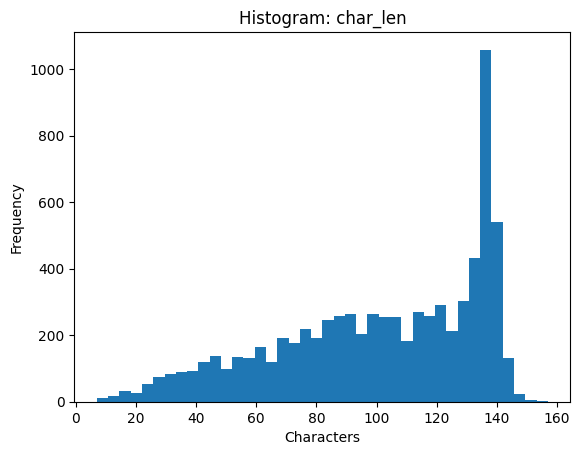

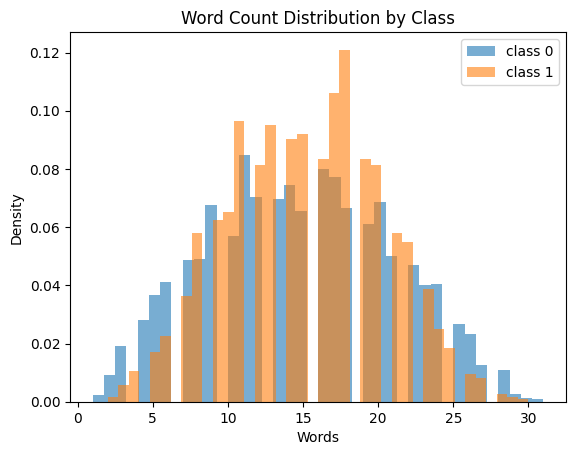

In [ ]:
# --- 5) Feature engineering (numeric features like your EOS project) ---
def add_numeric_features(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)
    text = df["text"].fillna("").astype(str)

    out["char_len"] = text.str.len()
    out["word_count"] = text.apply(lambda x: len(x.split()))
    out["exclaim_count"] = text.str.count("!")
    out["question_count"] = text.str.count(r"\?")
    out["has_url"] = text.str.contains(URL_RE).astype(int)
    out["mention_count"] = text.str.count(MENTION_RE)
    out["hashtag_count"] = text.str.count(r"#\w+")
    out["caps_ratio"] = text.apply(lambda x: (sum(1 for ch in x if ch.isupper()) / max(1, len(x))))
    out["digit_count"] = text.str.count(r"\d")
    return out

# quick look + plots
num_feats = add_numeric_features(train_df)
display(num_feats.describe().T)

plt.figure()
num_feats["char_len"].plot(kind="hist", bins=40)
plt.title("Histogram: char_len")
plt.xlabel("Characters")
plt.show()

plt.figure()
for c in [0, 1]:
    num_feats.loc[train_df["target"] == c, "word_count"].plot(kind="hist", bins=40, alpha=0.6, density=True, label=f"class {c}")
plt.title("Word Count Distribution by Class")
plt.xlabel("Words")
plt.ylabel("Density")
plt.legend()
plt.show()

In [ ]:
# --- 6) Build modeling dataframe ---
X = train_df[["text"]].copy()
y = train_df["target"].astype(int).copy()

X_test = test_df[["text"]].copy()

# We'll pass raw text + numeric features using a FunctionTransformer
def make_model_frame(df):
    # output includes "clean_text" + engineered numeric columns
    out = pd.DataFrame(index=df.index)
    out["clean_text"] = df["text"].apply(clean_text)
    out = pd.concat([out, add_numeric_features(df)], axis=1)
    return out

X_model = make_model_frame(train_df)
X_test_model = make_model_frame(test_df)

display(X_model.head())

,clean_text,char_len,word_count,exclaim_count,question_count,has_url,mention_count,hashtag_count,caps_ratio,digit_count
0,our deeds are the reason of this earthquake ma...,69,13,0,0,0,0,1,0.144928,0
1,forest fire near la ronge sask canada,38,7,0,0,0,0,0,0.131579,0
2,all residents asked to 'shelter in place' are ...,133,22,0,0,0,0,0,0.015038,0
3,13 000 people receive wildfires evacuation ord...,65,8,0,0,0,0,1,0.015385,5
4,just got sent this photo from ruby alaska as s...,88,16,0,0,0,0,2,0.034091,0


In [ ]:
# --- 7) Pipeline: TF-IDF on clean_text + scaled numeric features ---
text_col = "clean_text"
numeric_cols = [c for c in X_model.columns if c != text_col]

preprocess = ColumnTransformer(
    transformers=[
        ("tfidf", TfidfVectorizer(
            ngram_range=(1,2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        ), text_col),
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler(with_mean=False))
        ]), numeric_cols)
    ],
    remainder="drop"
)

# Two strong baselines
logreg = LogisticRegression(max_iter=3000, n_jobs=None, class_weight=None)
linsvc = LinearSVC()

pipe_logreg = Pipeline(steps=[("prep", preprocess), ("model", logreg)])
pipe_linsvc = Pipeline(steps=[("prep", preprocess), ("model", linsvc)])

In [ ]:
# --- 8) Cross-validation (F1) ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scores_lr = cross_val_score(pipe_logreg, X_model, y, cv=cv, scoring="f1")
scores_svc = cross_val_score(pipe_linsvc, X_model, y, cv=cv, scoring="f1")

print("LogReg CV F1:", scores_lr, "mean:", scores_lr.mean())
print("LinSVC CV F1:", scores_svc, "mean:", scores_svc.mean())

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LogReg CV F1: [0.76086957 0.74562135 0.72757475 0.74706868 0.76363636] mean: 0.748954141505435
LinSVC CV F1: [0.75697211 0.76129032 0.73625498 0.7388844  0.74358974] mean: 0.7473983111080628


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Using baseline: LogisticRegression
Validation F1: 0.7596390484003281


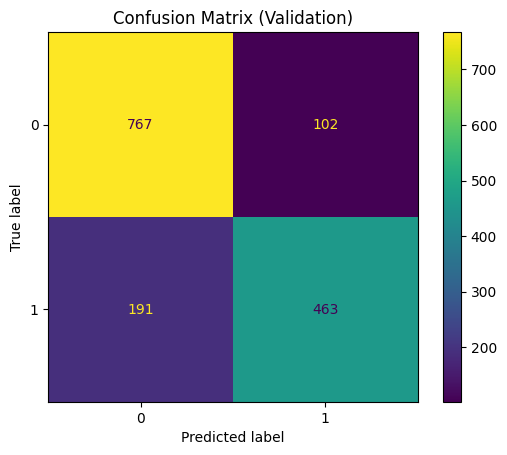

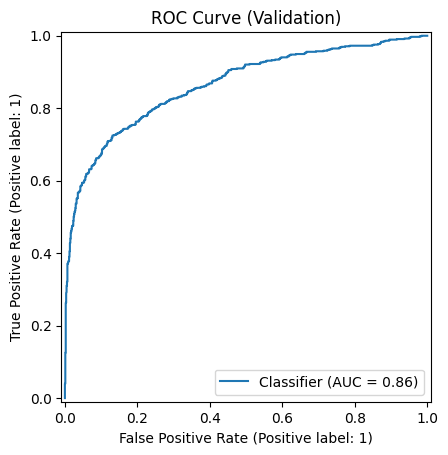

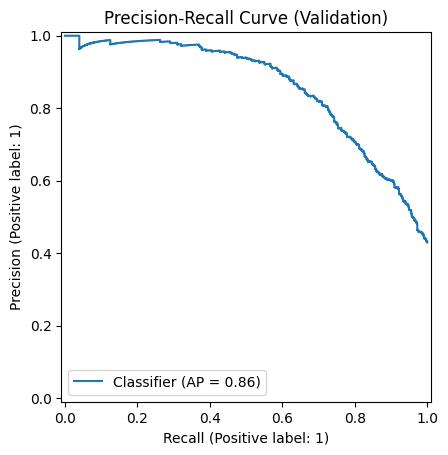

In [ ]:
# --- 9) Train/valid split + diagnostics plots (confusion matrix, PR, ROC where possible) ---
X_tr, X_va, y_tr, y_va = train_test_split(
    X_model, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Choose the better baseline based on CV mean
best_pipe = pipe_linsvc if scores_svc.mean() >= scores_lr.mean() else pipe_logreg
print("Using baseline:", best_pipe.named_steps["model"].__class__.__name__)

best_pipe.fit(X_tr, y_tr)
pred = best_pipe.predict(X_va)

print("Validation F1:", f1_score(y_va, pred))

cm = confusion_matrix(y_va, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(values_format="d")
plt.title("Confusion Matrix (Validation)")
plt.show()

# For ROC/PR: needs scores/probabilities
# LinSVC has decision_function; LogisticRegression has predict_proba
if hasattr(best_pipe.named_steps["model"], "predict_proba"):
    scores = best_pipe.predict_proba(X_va)[:, 1]
elif hasattr(best_pipe.named_steps["model"], "decision_function"):
    scores = best_pipe.decision_function(X_va)
else:
    scores = None

if scores is not None:
    RocCurveDisplay.from_predictions(y_va, scores)
    plt.title("ROC Curve (Validation)")
    plt.show()

    PrecisionRecallDisplay.from_predictions(y_va, scores)
    plt.title("Precision-Recall Curve (Validation)")
    plt.show()

In [ ]:
# --- 10) Hyperparameter tuning (RandomizedSearchCV) ---
# Tune only the model + a couple tfidf settings (keeps it fast & effective)
param_distributions = []

# If baseline is LogisticRegression:
if best_pipe.named_steps["model"].__class__.__name__ == "LogisticRegression":
    param_distributions = {
        "prep__tfidf__ngram_range": [(1,1), (1,2)],
        "prep__tfidf__min_df": [1, 2, 3, 5],
        "prep__tfidf__max_df": [0.9, 0.95, 0.98],
        "model__C": np.logspace(-2, 2, 20),
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs"]
    }
else:
    # LinearSVC
    param_distributions = {
        "prep__tfidf__ngram_range": [(1,1), (1,2)],
        "prep__tfidf__min_df": [1, 2, 3, 5],
        "prep__tfidf__max_df": [0.9, 0.95, 0.98],
        "model__C": np.logspace(-2, 2, 25)
    }

search = RandomizedSearchCV(
    best_pipe,
    param_distributions=param_distributions,
    n_iter=25,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

search.fit(X_model, y)
print("Best CV F1:", search.best_score_)
print("Best params:", search.best_params_)

best_tuned = search.best_estimator_

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best CV F1: 0.7591851689028027
Best params: {'prep__tfidf__ngram_range': (1, 1), 'prep__tfidf__min_df': 3, 'prep__tfidf__max_df': 0.9, 'model__solver': 'lbfgs', 'model__penalty': 'l2', 'model__C': np.float64(2.06913808111479)}


In [ ]:
# --- 11) Fit tuned model on full train + create submission ---
best_tuned.fit(X_model, y)
test_pred = best_tuned.predict(X_test_model)

submission = sub_df.copy()
submission["target"] = test_pred.astype(int)

submission_path = "submission_updated.csv"
submission.to_csv(submission_path, index=False)

submission.head(), submission_path

(   id  target
 0   0       1
 1   2       0
 2   3       1
 3   9       0
 4  11       1,
 'submission_updated.csv')

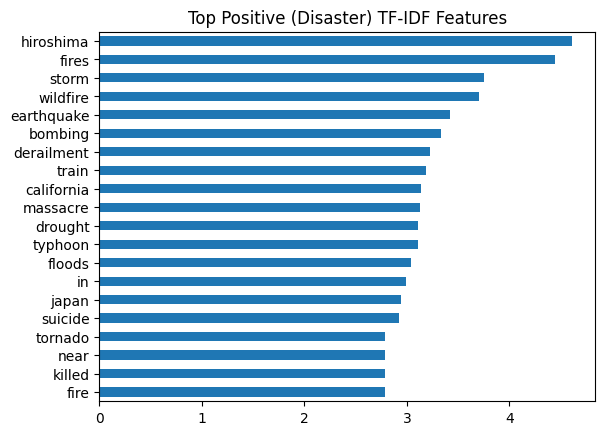

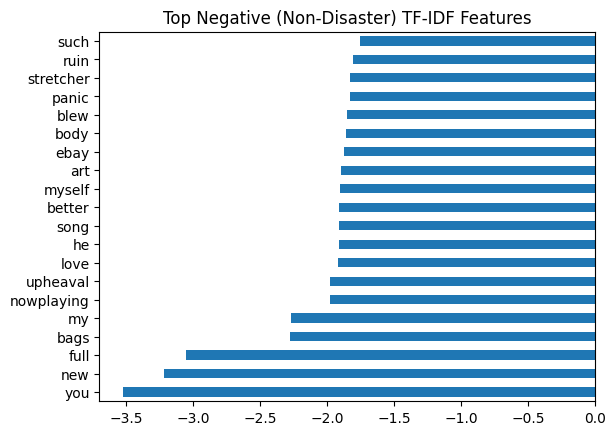

In [ ]:
# --- 12) Extra: quick plot of top TF-IDF features (works best with LogisticRegression) ---
# If tuned model is LogisticRegression, we can inspect coefficients
model = best_tuned.named_steps["model"]
prep = best_tuned.named_steps["prep"]

if model.__class__.__name__ == "LogisticRegression":
    tfidf = prep.named_transformers_["tfidf"]
    feature_names = tfidf.get_feature_names_out()

    # Note: ColumnTransformer outputs [tfidf features] then [numeric features]
    coefs = model.coef_.ravel()
    tfidf_coefs = coefs[:len(feature_names)]

    top_pos_idx = np.argsort(tfidf_coefs)[-20:][::-1]
    top_neg_idx = np.argsort(tfidf_coefs)[:20]

    top_pos = pd.Series(tfidf_coefs[top_pos_idx], index=feature_names[top_pos_idx])
    top_neg = pd.Series(tfidf_coefs[top_neg_idx], index=feature_names[top_neg_idx])

    plt.figure()
    top_pos.sort_values().plot(kind="barh")
    plt.title("Top Positive (Disaster) TF-IDF Features")
    plt.show()

    plt.figure()
    top_neg.sort_values().plot(kind="barh")
    plt.title("Top Negative (Non-Disaster) TF-IDF Features")
    plt.show()
else:
    print("Feature importance plot skipped (not LogisticRegression).")